# CIA: Controllable Image Augmentation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fennecinspace/ciagen/blob/main/notebooks/CIA_Quickstart.ipynb)

[![arXiv](https://img.shields.io/badge/arXiv-2411.16128-blue)](https://arxiv.org/abs/2411.16128)

**CIA** (Controllable Image Augmentation) is a Python library for synthetic data augmentation using Stable Diffusion + ControlNet.

This notebook demonstrates how to:
1. Install CIA
2. Generate synthetic images from real images
3. Evaluate generation quality
4. Filter the best images
5. Generate and collapse captions

## 1. Installation

In [24]:
!pip install ciagen matplotlib pillow
!pip install -e ..

Obtaining file:///home/mohamed/Projects/synthetic-augmentation
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ciagen (pyproject.toml) ... done
  Created wheel for ciagen: filename=ciagen-1.0.0-0.editable-py3-none-any.whl size=18170 sha256=5b3d975482da6029e72e5601a041dcef01c6f2e857a1102b6fbc1668e0545d04
  Stored in directory: /tmp/pip-ephem-wheel-cache-n9m05u25/wheels/1a/8e/eb/56e0bcee10268ad85b6cd17c2ec756afc336c0097787dbfdeb
Successfully built ciagen
  Attempting uninstall: ciagen
    Found existing installation: ciagen 1.0.0
    Uninstalling ciagen-1.0.0:
      Successfully uninstalled ciagen-1.0.0


In [25]:
import ciagen
print("Available functions:", ciagen.__all__)

Available functions: ['generate', 'evaluate', 'filter_generated', 'caption']


## 2. Setup: Download sample images

We'll download a few sample images to use as source images.

In [19]:
import urllib.request
from pathlib import Path

sample_dir = Path("sample_images")
sample_dir.mkdir(exist_ok=True)

sample_images = [
    ("https://www.laborfinders.com/media/ce4gdtvi/women-in-construction.png", "samples001.png"),
    ("https://thehimalayantimes.com/uploads/imported_images/wp-content/uploads/2020/07/Kathmandu-movement.jpg", "samples002.png"),
    ("https://www.vlitefurnitech.com/wp-content/uploads/2024/11/View-of-cabin-office-scaled.webp", "samples003.png"),
]

for url, filename in sample_images:
    try:
        urllib.request.urlretrieve(url, sample_dir / filename)
        print(f"Downloaded {filename}")
    except Exception as e:
        print(f"Failed to download {filename}: {e}")

print(f"\nDownloaded {len(list(sample_dir.glob('*')))} images to {sample_dir}")

Downloaded samples001.png
Downloaded samples002.png
Downloaded samples003.png

Downloaded 6 images to sample_images


## 3. Visualize source images

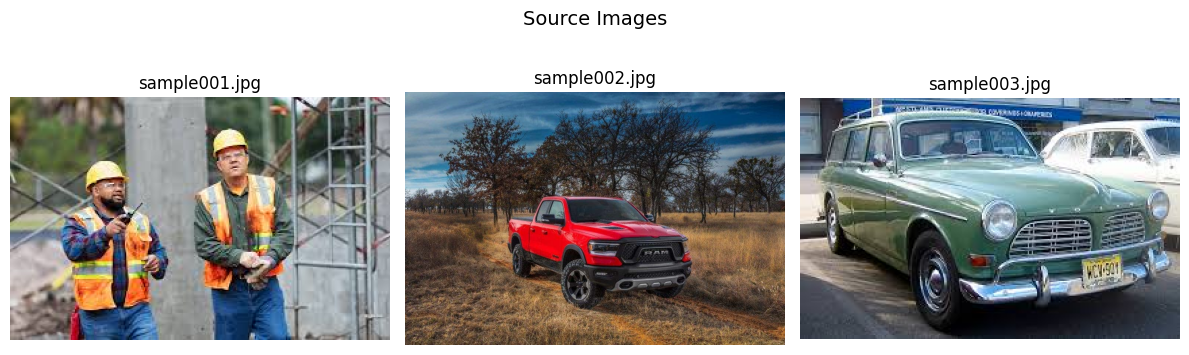

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

images = sorted(sample_dir.glob("*"))
fig, axes = plt.subplots(1, min(3, len(images)), figsize=(12, 4))
if len(images) == 1:
    axes = [axes]
for ax, img_path in zip(axes, images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")
plt.suptitle("Source Images", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Generate synthetic images

We use Canny edge detection as the control condition. This preserves the overall structure while allowing the model to generate new versions.

**Note**: This requires a GPU. If running on CPU, reduce `num_per_image` to 1.

In [27]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cpu":
    print("Warning: GPU recommended for generation. This will be slow on CPU.")

Using device: cuda


In [28]:
from pathlib import Path

output_dir = Path("generated_images")
output_dir.mkdir(exist_ok=True)

result = ciagen.generate(
    source=str(sample_dir),
    output=str(output_dir),
    extractor="canny",
    sd_model="fennecinspace/sd-v15",
    cn_model="lllyasviel/sd-controlnet-canny",
    num_per_image=2,
    prompt="a high quality photo",
    seed=42,
    device=device,
)

print(f"\nGenerated {result['total_generated']} images")
print(f"Output: {result['output_path']}")

Loading pipeline components...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.03it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


ModuleNotFoundError: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers

## 5. Visualize generated images

Compare the original and synthetic images side by side.

In [ ]:
gen_images = sorted(output_dir.glob("*.png"))
if gen_images:
    n_show = min(6, len(gen_images))
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, img_path in zip(axes.flat, gen_images[:n_show]):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=10)
        ax.axis("off")
    plt.suptitle("Generated Synthetic Images", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No generated images found.")

## 6. Evaluate quality

Compute FID (Frechet Inception Distance) and Mahalanobis distance to assess how well the synthetic images match the real distribution.

In [ ]:
from pathlib import Path

scores = ciagen.evaluate(
    real=str(sample_dir),
    generated=str(output_dir),
    metrics=["mld"],
    feature_extractor="vit",
)

print("Per-image Mahalanobis distances:")
for img_path, distance in scores["ptd"]["mld"].items():
    print(f"  {Path(img_path).name}: {distance:.4f}")

## 7. Filter by quality

Keep only the best images based on the quality scores.

In [ ]:
kept = ciagen.filter_generated(
    generated=str(output_dir),
    method="top-k",
    value=3,
)

print("Filtered images:")
for metric_name, fe_data in kept.items():
    for fe_name, images in fe_data.items():
        print(f"  {metric_name}/{fe_name}: {len(images)} images kept")

## 8. Generate captions

Caption images using OpenRouter (free Gemini) or OpenAI.

**Note**: You need an API key from [openrouter.ai/keys](https://openrouter.ai/keys).

In [ ]:
import os
from pathlib import Path

captions_dir = Path("captions")
captions_dir.mkdir(exist_ok=True)

api_key = os.environ.get("OPENROUTER_API_KEY", None)
if api_key is None:
    print("No OpenRouter API key found. Set OPENROUTER_API_KEY environment variable.")
    print("Get a free key at: https://openrouter.ai/keys")
else:
    print("OpenRouter API key loaded.")

In [ ]:
if api_key and gen_images:
    ciagen.caption(
        images=str(gen_images[0].parent),
        captions_dir=str(captions_dir),
        engine="openrouter",
        model="google/gemini-2.0-flash-001",
        api_key=api_key,
    )
    print(f"Captions saved to {captions_dir}")

### Collapsing multiline captions into a single line

AI models often return captions with line breaks. For use as prompts or training labels,
it's useful to collapse these into a single line. The `read_caption` function handles this automatically during generation.

In [ ]:
import re

def collapse_caption(caption: str) -> str:
    """Collapse multiline caption into a single line."""
    return re.sub(r"\s+", " ", caption.strip())

caption_files = list(captions_dir.glob("*.txt"))
if caption_files:
    print(f"Found {len(caption_files)} captions:\n")
    for cap_file in caption_files:
        original = cap_file.read_text()
        collapsed = collapse_caption(original)
        print(f"{cap_file.name}:")
        print(f"  Original:   {repr(original[:80])}...")
        print(f"  Collapsed:   {collapsed[:80]}...")
        print()
        # Save collapsed version
        cap_file.write_text(collapsed)
else:
    print("No captions found.")

## What's next?

- **[Documentation](https://ciagen.readthedocs.io)**: Full API reference and guides
- **[GitHub](https://github.com/fennecinspace/ciagen)**: Source code and examples
- **[arXiv Paper](https://arxiv.org/abs/2411.16128)**: Learn about the methodology

### Available extractors:

| Extractor | Description |
|-----------|-------------|
| `canny` | Canny edge detection (shown above) |
| `openpose` | Human pose estimation |
| `segmentation` | Semantic segmentation |
| `mediapipe_face` | Face landmarks |